In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
miles_data = np.load("/home/arbiter/projects/Recalibration-deep-learning/data/MILES_spectra.npz")
cflib_data = np.load("/home/arbiter/projects/Recalibration-deep-learning/data/cflib_data.npz", allow_pickle= True)

In [9]:
miles_star_flux = miles_data["flux_array"]
print(miles_star_flux)
print(f"Number of datapoints/stars : {len(miles_star_flux)}")
print(f"length of wavelength grid : {len(miles_star_flux[0])}")

[[2.800326   2.820038   2.8403442  ... 0.26744303 0.2683123  0.27005458]
 [0.20480944 0.19794364 0.2035859  ... 0.8984447  0.88135725 0.87744087]
 [0.14189121 0.1389648  0.13865823 ... 0.94967973 0.93322724 0.93082297]
 ...
 [0.17056978 0.18025438 0.17833976 ... 1.1286676  1.1464667  1.1668826 ]
 [0.11795986 0.17964727 0.20128004 ... 1.123267   1.1062928  1.120373  ]
 [0.30222747 0.3139706  0.32807022 ... 0.6965927  0.6794233  0.6928694 ]]
Number of datapoints/stars : 985
length of wavelength grid : 4306


In [8]:
cflib_star_flux = cflib_data["flux"]
print(cflib_star_flux)
print(f"Number of datapoints/stars : {len(cflib_star_flux)}")
print(f"length of wavelength grid : {len(cflib_star_flux[0])}")

[[1.176708573333929 1.1760512221903987 1.173074399498486 ...
  0.4122635493170717 0.41270305790417994 0.41297965237073375]
 [0.040143816502474255 0.03955856424195762 0.04061330881936796 ...
  1.5610761752147815 1.5627929888600045 1.540046457921836]
 [0.22926749402309268 0.2314625184640081 0.23468264525356838 ...
  0.8415991414094556 0.838740358780529 0.8269542794439935]
 ...
 [0.6101351547497081 0.6073226639791796 0.6103089534498088 ...
  9.85354519046036e-05 9.85354519046036e-05 9.85354519046036e-05]
 [0.44463511811891404 0.4444143500137974 0.44083050760027165 ...
  9.190256391646997e-05 9.190256391646997e-05 9.190256391646997e-05]
 [0.5969016523678589 0.5911757758409714 0.5920322877247359 ...
  0.6558381072735252 0.6582127407132922 0.6568357492659957]]
Number of datapoints/stars : 850
length of wavelength grid : 4367


Masking CFLIB wavelength grid

In [10]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))

In [11]:
input_flux = []
for i in range(len(cflib_star_flux)):
    input_flux.append(cflib_star_flux[i][low_idx : high_idx + 1])
    
input_flux = np.array(input_flux)

In [12]:
print(input_flux)
print(f"Number of datapoints/stars : {len(input_flux)}")
print(f"length of wavelength grid : {len(input_flux[0])}")

[[1.1825487646914092 1.1841432511841439 1.1860783470682998 ...
  0.4124035574007773 0.4105880111693166 0.4107658742488486]
 [0.05012359158249259 0.05087644314420091 0.05242872825483944 ...
  1.470013205194036 1.4559561793877915 1.4632705648224837]
 [0.2362234472559823 0.23218703652067837 0.23380249477842624 ...
  0.7866333409396982 0.7716400516481633 0.7752994451876409]
 ...
 [0.6531245140554456 0.6494315947886485 0.6536496646603588 ...
  9.85354519046036e-05 9.85354519046036e-05 9.85354519046036e-05]
 [0.40733122403375077 0.38788939127494076 0.39513174101918763 ...
  9.190256391646997e-05 9.190256391646997e-05 9.190256391646997e-05]
 [0.6186189577056762 0.622308238396077 0.6300363299913472 ...
  0.6388013675444142 0.6380960935140043 0.6365599939693225]]
Number of datapoints/stars : 850
length of wavelength grid : 4306


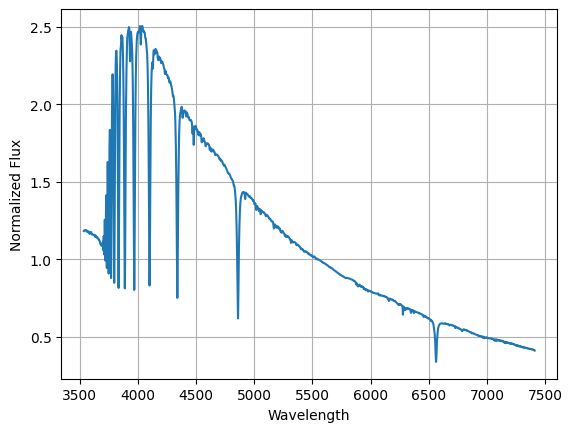

In [ ]:
wavelength_grid = 3536. + np.arange(4306) * 0.9
plt.plot(wavelength_grid , input_flux[0])
plt.grid()
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.show()

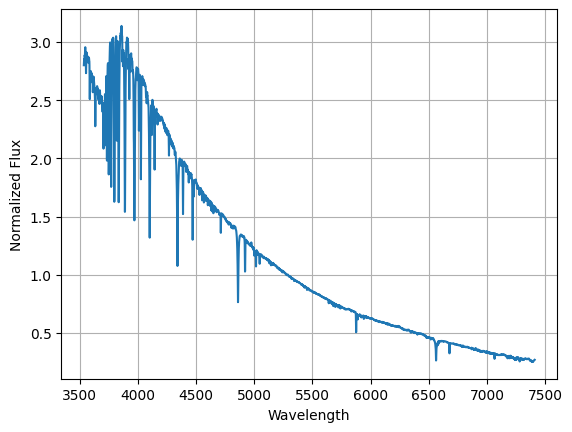

In [17]:
plt.plot(wavelength_grid , miles_star_flux[0])
plt.grid()
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.show()